In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
import os
os.environ["LD_PRELOAD"]

'/lib64/libXrdPosixPreload.so:libnss_wrapper.so'

In [3]:
!ls /pnfs/sbnd/scratch/users/munjung/v10_06_00/raw-SBND_DATA_InTimeCosmics_offbeamlight/waveforms/

ls: cannot access '/pnfs/sbnd/scratch/users/munjung/v10_06_00/raw-SBND_DATA_InTimeCosmics_offbeamlight/waveforms/': No such file or directory


In [4]:
def pnfs2xrootd(fname):
    return fname.replace("/pnfs", "root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr")
    

In [6]:
fname = "/pnfs/sbnd/scratch/users/munjung/v10_06_00/raw-SBND_DATA_InTimeCosmics_offbeamlight/waveforms/27333755_1109/g4-raw-0_1.h5"


def visualize(img):
    return np.clip(img, -1, 1)

with h5py.File(pnfs2xrootd(fname), "r") as f:
    # scale charge by 500
    arrs = [f[ev]["raw"][:] for ev in f.keys()]
allarrs = []
for arr in arrs:
    nrows, ncols = (512, 512)
    plane_boundaries = [0, 1984, 3968, 5638]
    for planeno, (wlo, whi) in enumerate(zip(plane_boundaries[:-1], plane_boundaries[1:])):
        planearr = arr[wlo:whi, :]
        h, w = planearr.shape
        ll = planearr[:(h//nrows)*nrows, :(w//nrows)*nrows].reshape(h//nrows, nrows, -1, ncols).swapaxes(1,2).reshape(-1, nrows, ncols)
        cscale = [200., 100., 200.][planeno]
        allarrs.append(ll/cscale)
        
imgs = visualize(np.expand_dims(np.concatenate(allarrs), axis=1)).astype(np.float32)

In [7]:
imgs.shape

(540, 1, 512, 512)

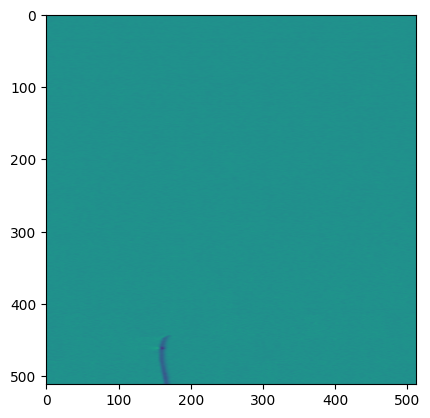

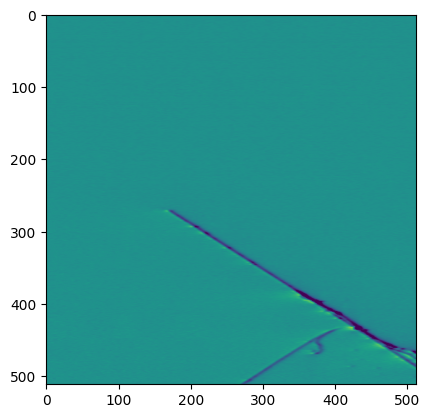

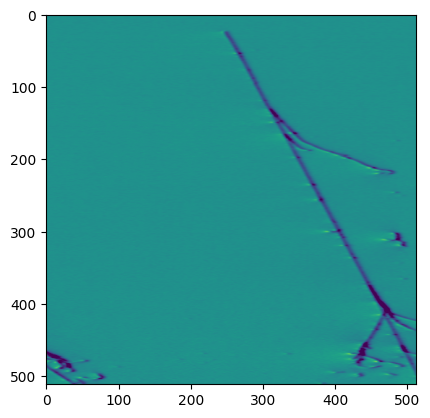

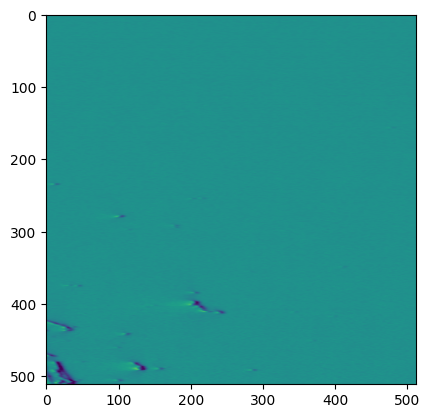

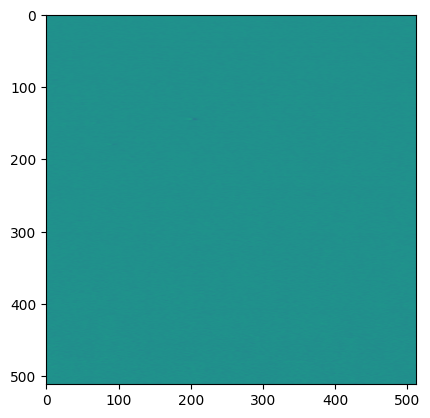

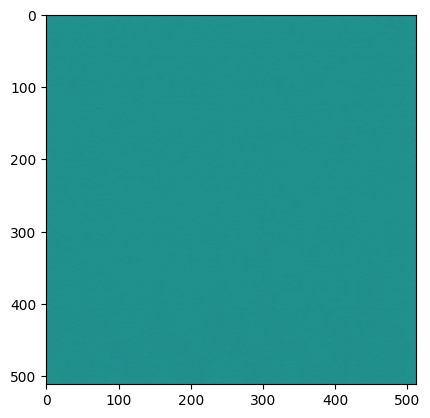

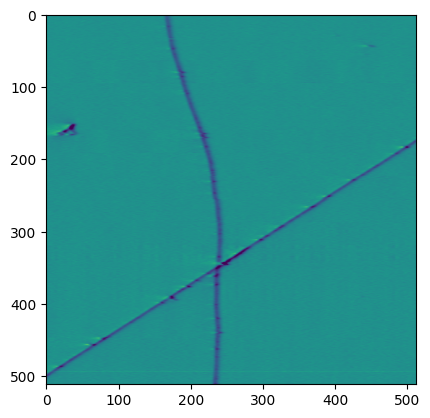

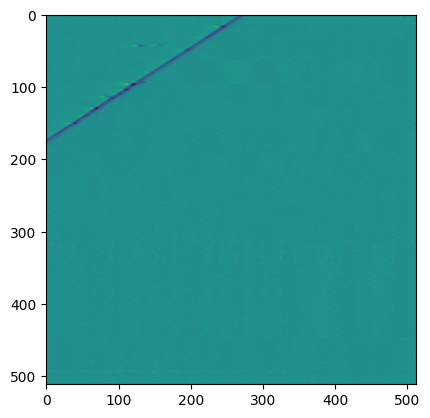

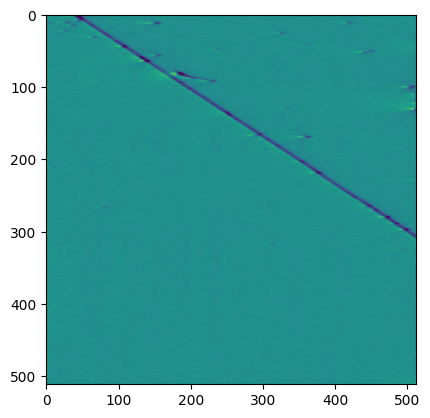

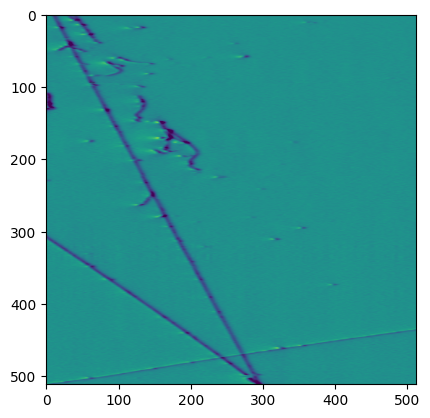

In [9]:
for i in range(10):
    plt.figure(i)
    plt.imshow(np.squeeze(imgs[i]), vmin=-0.5, vmax=0.5)